In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import os

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [8]:
# Load your data
df = pd.read_excel('../data/processed/cleaned_disaster_dataset.xlsx')  
print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Identify feature columns (exclude target)
target_col = 'disaster_type_encoded'
feature_cols = [col for col in df.columns if col != target_col]

# Handle any remaining missing values
X = df[feature_cols].fillna(0)
y = df[target_col]

print(f"\nFeatures: {len(feature_cols)} columns")
print(f"Target classes: {y.nunique()}")

# Class distribution
print("\nClass distribution:")
class_counts = y.value_counts().sort_index()
for cls, count in class_counts.items():
    print(f"  Class {cls}: {count} ({count/len(y)*100:.1f}%)")

# Check imbalance ratio
min_count = class_counts.min()
max_count = class_counts.max()
imbalance_ratio = max_count / min_count
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 5:
    print("⚠️ Severe class imbalance detected! SMOTE recommended.")
else:
    print("✅ Relatively balanced dataset.")

Data loaded: 17474 rows, 34 columns

Features: 33 columns
Target classes: 8

Class distribution:
  Class 0: 803 (4.6%)
  Class 1: 1651 (9.4%)
  Class 2: 1622 (9.3%)
  Class 3: 730 (4.2%)
  Class 4: 6183 (35.4%)
  Class 5: 918 (5.3%)
  Class 6: 5053 (28.9%)
  Class 7: 514 (2.9%)

Imbalance Ratio: 12.03:1
⚠️ Severe class imbalance detected! SMOTE recommended.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nClass distribution (training):")
train_counts = pd.Series(y_train).value_counts().sort_index()
for cls, count in train_counts.items():
    print(f"  Class {cls}: {count} ({count/len(y_train)*100:.1f}%)")

Training set: 13979 samples
Test set: 3495 samples

Class distribution (training):
  Class 0: 643 (4.6%)
  Class 1: 1321 (9.4%)
  Class 2: 1298 (9.3%)
  Class 3: 584 (4.2%)
  Class 4: 4946 (35.4%)
  Class 5: 734 (5.3%)
  Class 6: 4042 (28.9%)
  Class 7: 411 (2.9%)


In [10]:
print("=" * 70)
print("STEP 4: DEFINING MODELS WITH SMOTE")
print("=" * 70)

# Pipeline: SMOTE + StandardScaler + Model
def create_smote_pipeline(model):
    """Create a pipeline with SMOTE and the given model."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', model)
    ])

# Define models with SMOTE
models_with_smote = {
    'Logistic Regression + SMOTE': create_smote_pipeline(
        LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', class_weight='balanced')
    ),
    'Random Forest + SMOTE': create_smote_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    ),
    'Decision Tree + SMOTE': create_smote_pipeline(
        DecisionTreeClassifier(random_state=42, class_weight='balanced')
    ),
    'SVM (RBF) + SMOTE': create_smote_pipeline(
        SVC(kernel='rbf', random_state=42, class_weight='balanced', probability=True)
    ),
    'Naive Bayes + SMOTE': create_smote_pipeline(
        GaussianNB()
    ),
    'XGBoost + SMOTE': create_smote_pipeline(
        XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                      random_state=42, eval_metric='mlogloss')
    )
}

# Also define models WITHOUT SMOTE for comparison
models_without_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, 
                                             multi_class='multinomial', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, class_weight='balanced', probability=True),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=42, eval_metric='mlogloss')
}

print(f"Total models with SMOTE: {len(models_with_smote)}")
print(f"Total models without SMOTE: {len(models_without_smote)}")

STEP 4: DEFINING MODELS WITH SMOTE
Total models with SMOTE: 6
Total models without SMOTE: 6


In [11]:
print("=" * 70)
print("STEP 5: CROSS-VALIDATION EVALUATION (5-Fold CV)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print("\nEvaluating models WITH SMOTE:")
for name, model in models_with_smote.items():
    try:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
        cv_results[name] = {
            'CV F1-Macro': scores.mean(),
            'CV Std': scores.std()
        }
        print(f"{name:<35} F1-Macro: {scores.mean():.4f} (+/- {scores.std():.4f})")
    except Exception as e:
        print(f"{name:<35} Error: {str(e)[:50]}...")
        cv_results[name] = {'CV F1-Macro': 0.0, 'CV Std': 0.0}

cv_df = pd.DataFrame(cv_results).T
print("\n" + cv_df.to_string())

STEP 5: CROSS-VALIDATION EVALUATION (5-Fold CV)

Evaluating models WITH SMOTE:
Logistic Regression + SMOTE         F1-Macro: 0.7362 (+/- 0.0068)
Random Forest + SMOTE               F1-Macro: 0.7782 (+/- 0.0057)
Decision Tree + SMOTE               F1-Macro: 0.7707 (+/- 0.0042)
SVM (RBF) + SMOTE                   F1-Macro: 0.7604 (+/- 0.0039)
Naive Bayes + SMOTE                 F1-Macro: 0.6412 (+/- 0.0398)
XGBoost + SMOTE                     F1-Macro: 0.7920 (+/- 0.0027)

                             CV F1-Macro    CV Std
Logistic Regression + SMOTE     0.736213  0.006762
Random Forest + SMOTE           0.778243  0.005664
Decision Tree + SMOTE           0.770660  0.004242
SVM (RBF) + SMOTE               0.760357  0.003902
Naive Bayes + SMOTE             0.641210  0.039836
XGBoost + SMOTE                 0.792049  0.002691


In [12]:
print("=" * 70)
print("STEP 6: TEST SET EVALUATION (WITH SMOTE)")
print("=" * 70)

test_results_with_smote = {}

for name, model in models_with_smote.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        acc = accuracy_score(y_test, y_pred)
        test_results_with_smote[name] = {
            'Test Accuracy': acc,
            'Test F1-Macro': f1
        }
        print(f"{name:<35} Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
    except Exception as e:
        print(f"{name:<35} Error: {str(e)[:50]}...")
        test_results_with_smote[name] = {'Test Accuracy': 0.0, 'Test F1-Macro': 0.0}

test_df_smote = pd.DataFrame(test_results_with_smote).T

STEP 6: TEST SET EVALUATION (WITH SMOTE)
Logistic Regression + SMOTE         Acc: 0.7740 | F1-Macro: 0.7370
Random Forest + SMOTE               Acc: 0.8529 | F1-Macro: 0.7819
Decision Tree + SMOTE               Acc: 0.8492 | F1-Macro: 0.7731
SVM (RBF) + SMOTE                   Acc: 0.8086 | F1-Macro: 0.7703
Naive Bayes + SMOTE                 Acc: 0.6475 | F1-Macro: 0.6469
XGBoost + SMOTE                     Acc: 0.8498 | F1-Macro: 0.7965


In [13]:
print("=" * 70)
print("STEP 7: TEST SET EVALUATION (WITHOUT SMOTE - BASELINE)")
print("=" * 70)

test_results_without_smote = {}

for name, model in models_without_smote.items():
    try:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        f1 = f1_score(y_test, y_pred, average='macro')
        acc = accuracy_score(y_test, y_pred)
        test_results_without_smote[name] = {
            'Test Accuracy': acc,
            'Test F1-Macro': f1
        }
        print(f"{name:<25} Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
    except Exception as e:
        print(f"{name:<25} Error: {str(e)[:50]}...")
        test_results_without_smote[name] = {'Test Accuracy': 0.0, 'Test F1-Macro': 0.0}

test_df_without_smote = pd.DataFrame(test_results_without_smote).T

STEP 7: TEST SET EVALUATION (WITHOUT SMOTE - BASELINE)
Logistic Regression       Acc: 0.7665 | F1-Macro: 0.7296
Random Forest             Acc: 0.8638 | F1-Macro: 0.7838
Decision Tree             Acc: 0.8469 | F1-Macro: 0.7742
SVM (RBF)                 Acc: 0.7943 | F1-Macro: 0.7575
Naive Bayes               Acc: 0.6635 | F1-Macro: 0.6591
XGBoost                   Acc: 0.9082 | F1-Macro: 0.8091


In [14]:

print("=" * 70)
print("STEP 8: SMOTE vs NO SMOTE COMPARISON")
print("=" * 70)

comparison_data = []

for base_name in models_without_smote.keys():
    smote_name = base_name + ' + SMOTE'
    
    f1_no_smote = test_results_without_smote[base_name]['Test F1-Macro']
    f1_smote = test_results_with_smote[smote_name]['Test F1-Macro']
    improvement = f1_smote - f1_no_smote
    
    comparison_data.append({
        'Model': base_name,
        'No SMOTE F1': f1_no_smote,
        'With SMOTE F1': f1_smote,
        'Improvement': improvement,
        'Better': '✅ SMOTE' if improvement > 0.01 else '✅ No SMOTE' if improvement < -0.01 else '≈ Equal'
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + comparison_df.to_string(index=False))

# Find best model with SMOTE
best_smote_name = max(test_results_with_smote, key=lambda x: test_results_with_smote[x]['Test F1-Macro'])
best_smote_f1 = test_results_with_smote[best_smote_name]['Test F1-Macro']

print(f"\n✅ BEST MODEL WITH SMOTE: {best_smote_name}")
print(f"   Test F1-Macro: {best_smote_f1:.4f}")

# Find best model without SMOTE
best_no_smote_name = max(test_results_without_smote, key=lambda x: test_results_without_smote[x]['Test F1-Macro'])
best_no_smote_f1 = test_results_without_smote[best_no_smote_name]['Test F1-Macro']

print(f"\n✅ BEST MODEL WITHOUT SMOTE: {best_no_smote_name}")
print(f"   Test F1-Macro: {best_no_smote_f1:.4f}")

STEP 8: SMOTE vs NO SMOTE COMPARISON

              Model  No SMOTE F1  With SMOTE F1  Improvement     Better
Logistic Regression     0.729646       0.737004     0.007358    ≈ Equal
      Random Forest     0.783832       0.781891    -0.001941    ≈ Equal
      Decision Tree     0.774233       0.773136    -0.001097    ≈ Equal
          SVM (RBF)     0.757492       0.770344     0.012853    ✅ SMOTE
        Naive Bayes     0.659062       0.646864    -0.012197 ✅ No SMOTE
            XGBoost     0.809120       0.796514    -0.012606 ✅ No SMOTE

✅ BEST MODEL WITH SMOTE: XGBoost + SMOTE
   Test F1-Macro: 0.7965

✅ BEST MODEL WITHOUT SMOTE: XGBoost
   Test F1-Macro: 0.8091


In [15]:
print("=" * 70)
print("STEP 9: CV vs Test F1-Macro Comparison (With SMOTE)")
print("=" * 70)

print("\nCV vs Test F1-Macro comparison:")
print(f"{'Model':<35}  {'CV F1-Mac':>10}  {'Test F1-Mac':>11}  {'Gap':>8}  {'Status':>10}")
print("-" * 85)

for name in models_with_smote.keys():
    cv_f1 = cv_results[name]['CV F1-Macro']
    tst_f1 = test_results_with_smote[name]['Test F1-Macro']
    gap = tst_f1 - cv_f1
    
    if gap < -0.05:
        status = "⚠️ Overfit"
    elif gap > 0.05:
        status = "✅ Underfit"
    else:
        status = "✓ Stable"
    
    print(f"{name:<35}  {cv_f1:>10.4f}  {tst_f1:>11.4f}  {gap:>+8.4f}  {status:>10}")

STEP 9: CV vs Test F1-Macro Comparison (With SMOTE)

CV vs Test F1-Macro comparison:
Model                                 CV F1-Mac  Test F1-Mac       Gap      Status
-------------------------------------------------------------------------------------
Logistic Regression + SMOTE              0.7362       0.7370   +0.0008    ✓ Stable
Random Forest + SMOTE                    0.7782       0.7819   +0.0036    ✓ Stable
Decision Tree + SMOTE                    0.7707       0.7731   +0.0025    ✓ Stable
SVM (RBF) + SMOTE                        0.7604       0.7703   +0.0100    ✓ Stable
Naive Bayes + SMOTE                      0.6412       0.6469   +0.0057    ✓ Stable
XGBoost + SMOTE                          0.7920       0.7965   +0.0045    ✓ Stable


In [16]:
print("=" * 70)
print(f"STEP 10: HYPERPARAMETER TUNING - {best_smote_name}")
print("=" * 70)

# Extract base model name (remove ' + SMOTE')
base_model_name = best_smote_name.replace(' + SMOTE', '')

# Define parameter grids based on best model
if base_model_name == 'XGBoost':
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }
    base_clf = XGBClassifier(random_state=42, eval_metric='mlogloss')
    
elif base_model_name == 'Random Forest':
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__class_weight': ['balanced', None]
    }
    base_clf = RandomForestClassifier(random_state=42)
    
elif base_model_name == 'Logistic Regression':
    param_grid = {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__class_weight': ['balanced', None],
        'classifier__solver': ['lbfgs', 'liblinear']
    }
    base_clf = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
    
elif base_model_name == 'SVM (RBF)':
    param_grid = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    }
    base_clf = SVC(random_state=42, probability=True)
    
elif base_model_name == 'Decision Tree':
    param_grid = {
        'classifier__max_depth': [3, 5, 10, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__class_weight': ['balanced', None]
    }
    base_clf = DecisionTreeClassifier(random_state=42)
    
else:
    print(f"⚠️ No tuning defined for {base_model_name}. Skipping...")
    final_model = models_with_smote[best_smote_name]
    final_f1 = best_smote_f1
    param_grid = None

# Perform Grid Search if param_grid is defined
if 'param_grid' in locals() and param_grid is not None:
    # Create pipeline with SMOTE
    tune_pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
        ('classifier', base_clf)
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
        tune_pipeline,
        param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    
    print("\nSearching for best parameters...")
    grid_search.fit(X_train, y_train)
    
    print(f"\n✅ Best parameters: {grid_search.best_params_}")
    print(f"✅ Best CV F1-Macro: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    best_tuned = grid_search.best_estimator_
    y_pred_tuned = best_tuned.predict(X_test)
    best_tuned_f1 = f1_score(y_test, y_pred_tuned, average='macro')
    best_tuned_acc = accuracy_score(y_test, y_pred_tuned)
    
    print(f"\nTest Results (Tuned):")
    print(f"  Accuracy: {best_tuned_acc:.4f}")
    print(f"  F1-Macro: {best_tuned_f1:.4f}")
    
    if best_tuned_f1 > best_smote_f1:
        print(f"✅ Improvement over baseline SMOTE: +{best_tuned_f1 - best_smote_f1:.4f}")
        final_model = best_tuned
        final_f1 = best_tuned_f1
        final_acc = best_tuned_acc
        model_name = f"{base_model_name} + SMOTE + Tuned HP"
    else:
        print(f"⚠️ No improvement. Using baseline SMOTE model.")
        final_model = models_with_smote[best_smote_name]
        final_f1 = best_smote_f1
        final_acc = test_results_with_smote[best_smote_name]['Test Accuracy']
        model_name = best_smote_name
else:
    final_model = models_with_smote[best_smote_name]
    final_f1 = best_smote_f1
    final_acc = test_results_with_smote[best_smote_name]['Test Accuracy']
    model_name = best_smote_name

STEP 10: HYPERPARAMETER TUNING - XGBoost + SMOTE

Searching for best parameters...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/yazu/Library/Python/3.9/lib/python/s


✅ Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
✅ Best CV F1-Macro: 0.7994

Test Results (Tuned):
  Accuracy: 0.8578
  F1-Macro: 0.7979
✅ Improvement over baseline SMOTE: +0.0014


STEP 11: FEATURE IMPORTANCE

Top 10 most important features:
                                Feature  Importance
27       magnitude_scale_Morbidity rate    0.246991
26     magnitude_scale_Moment Magnitude    0.187184
29                   magnitude_scale_°C    0.162076
25                  magnitude_scale_Kph    0.157212
28           magnitude_scale_Vaccinated    0.152997
24                  magnitude_scale_Km2    0.051719
10           subregion_Northern America    0.004826
1                     magnitude_missing    0.004530
2   subregion_Australia and New Zealand    0.004171
30              total_deaths_normalized    0.003179


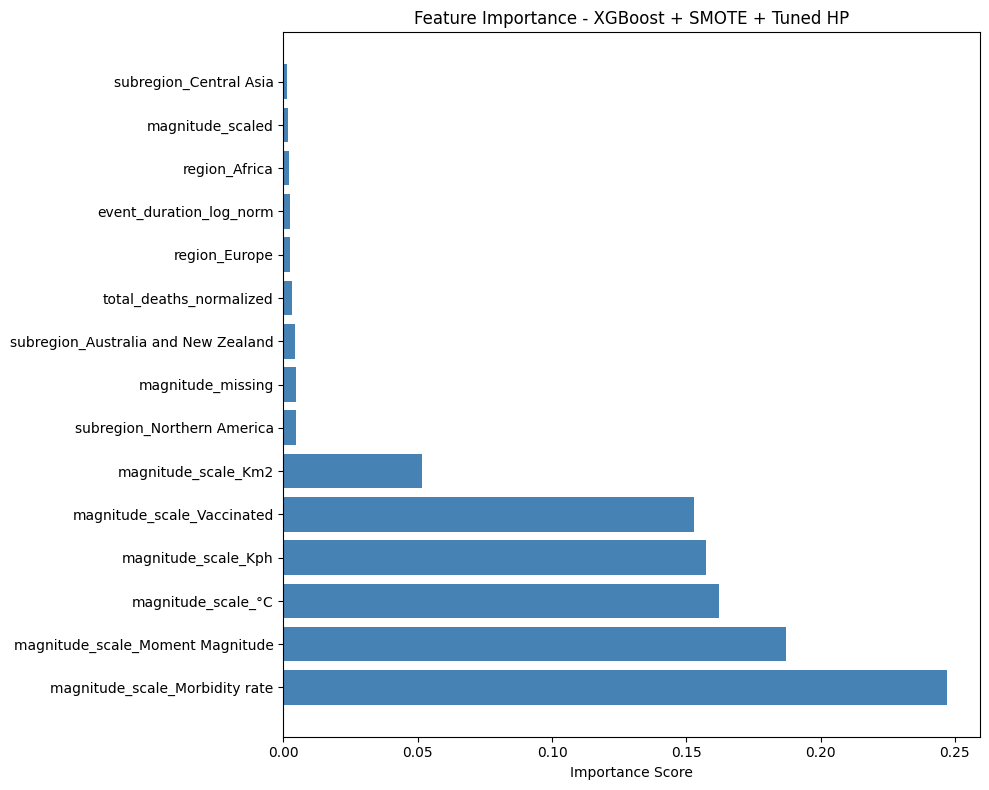

In [17]:
print("=" * 70)
print("STEP 11: FEATURE IMPORTANCE")
print("=" * 70)

# Get classifier from pipeline
if hasattr(final_model, 'named_steps'):
    classifier = final_model.named_steps['classifier']
else:
    classifier = final_model

# Check for feature importance
if hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 most important features:")
    print(importance_df.head(10))
    
    # Plot
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
    plt.title(f'Feature Importance - {model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance_with_smote.png', dpi=300, bbox_inches='tight')
    plt.show()
    
elif hasattr(classifier, 'coef_'):
    coefs = classifier.coef_.mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': coefs
    }).sort_values('Coefficient', ascending=False)
    
    print("\nTop 10 features (positive coefficients):")
    print(importance_df.head(10))
    
    print("\nBottom 10 features (negative coefficients):")
    print(importance_df.tail(10))
else:
    print(f"No feature importance available for {model_name}")

STEP 12: CONFUSION MATRIX - FINAL MODEL


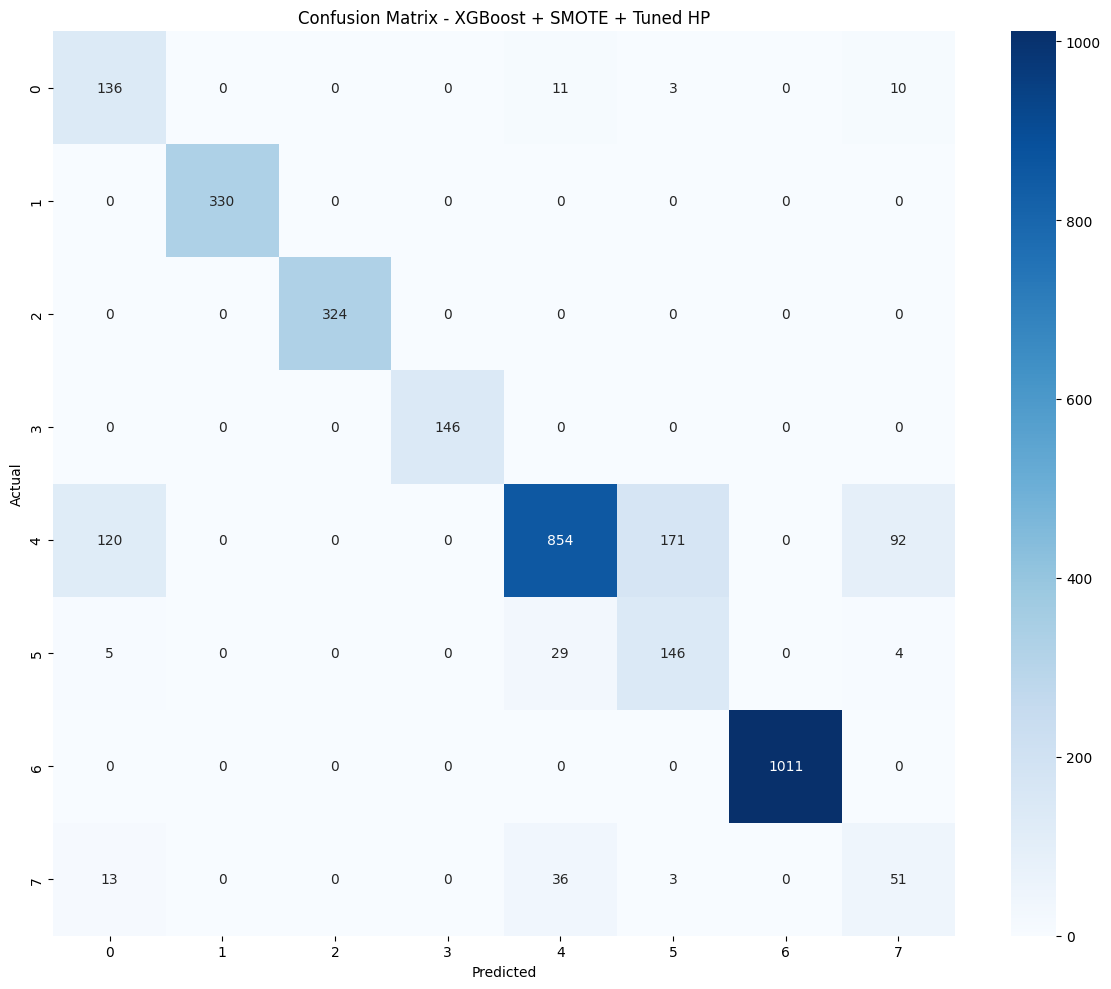


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.85      0.63       160
           1       1.00      1.00      1.00       330
           2       1.00      1.00      1.00       324
           3       1.00      1.00      1.00       146
           4       0.92      0.69      0.79      1237
           5       0.45      0.79      0.58       184
           6       1.00      1.00      1.00      1011
           7       0.32      0.50      0.39       103

    accuracy                           0.86      3495
   macro avg       0.77      0.85      0.80      3495
weighted avg       0.90      0.86      0.87      3495


Worst Performing Classes (by F1-Score):
   precision    recall  f1-score
7   0.324841  0.495146  0.392308
5   0.452012  0.793478  0.575937
0   0.496350  0.850000  0.626728
4   0.918280  0.690380  0.788186
1   1.000000  1.000000  1.000000


In [18]:
print("=" * 70)
print("STEP 12: CONFUSION MATRIX - FINAL MODEL")
print("=" * 70)

# Get final predictions
y_pred_final = final_model.predict(X_test)
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_smote_final.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Per-class performance analysis
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred_final, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report[~df_report.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
df_report_sorted = df_report.sort_values('f1-score')

print("\nWorst Performing Classes (by F1-Score):")
print(df_report_sorted[['precision', 'recall', 'f1-score']].head(5))

In [19]:

print("=" * 70)
print("STEP 13: SAVING FINAL MODEL")
print("=" * 70)

os.makedirs('models', exist_ok=True)

# Save
joblib.dump(final_model, 'models/final_model_with_smote.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Final model saved successfully!")
print("   - models/final_model_with_smote.pkl")
print("   - models/scaler.pkl")

# Save results summary
with open('models/results_summary_with_smote.txt', 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("FINAL MODEL RESULTS SUMMARY (WITH SMOTE)\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Best Model: {model_name}\n")
    f.write(f"Test F1-Macro: {final_f1:.4f}\n")
    f.write(f"Test Accuracy: {final_acc:.4f}\n")
    f.write(f"Features used: {len(feature_cols)}\n")
    f.write(f"\nSMOTE Used: Yes\n")
    f.write(f"Sampling Strategy: auto\n")

print("✅ Results saved to models/results_summary_with_smote.txt")

STEP 13: SAVING FINAL MODEL
✅ Final model saved successfully!
   - models/final_model_with_smote.pkl
   - models/scaler.pkl
✅ Results saved to models/results_summary_with_smote.txt
